# DSAN 5650 Final Project

## Imports

In [1]:
import pandas as pd 
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from fredapi import Fred
from pathlib import Path
import json
import requests
from urllib.request import urlopen
import plotly.io as pio
import os
from ipumspy import IpumsApiClient, MicrodataExtract, readers, ddi
import plotly.graph_objs as go
import pymc as pm
import arviz as az
import re
import pymc as pm
from scipy.special import logit
import xarray as xr

from utils import *

pio.renderers.default = "notebook"

/opt/anaconda3/envs/MyNewEnv/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (1.26.20) or chardet (7.4.0.post2)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(

In [2]:
with urlopen('https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json') as response:
    counties = json.load(response)

In [3]:
key_file_path = os.path.expanduser("~/api_keys.json")

with open(key_file_path, 'r') as file:
    api_key = json.load(file).get("ipums")

ipums = IpumsApiClient(api_key)

In [4]:
with open('/Users/Emi/api_keys.json') as f:
    api_keys = json.load(f)

## DOL Childcare Database

https://dataportal.dol.gov/datasets/10278

In [5]:
data = pd.read_excel("../assets/NDCP2022.xlsx")

In [6]:
sel_cols = ['STATE_NAME',
 'STATE_ABBREVIATION',
 'COUNTY_NAME',
 'COUNTY_FIPS_CODE',
 'STUDYYEAR',
 'MCBto5',
 'MC6to11',
 'MCINFANT',
 'MCTODDLER',
 'MCPRESCHOOL',
 'MFCCINFANT',
 'MFCCTODDLER',
 'MFCCPRESCHOOL',
 'FLFPR_20to64_UNDER6', # labor force participation rate of women with children under 6
 'FLFPR_20to64_6to17', # labor force participation rate of women with children 6 to 17
 'FLFPR_20to64_STATE', # womens lf participation rate by state,
 'FLFPR_20to64', # overall women's labor force participation rate (20-64) 
 'FME_2022', # median earnings for females in 2022 dollars
 'MME_2022', # median male earnings
 'MFI_2022'] # median family income in 2022

cc_df = data[sel_cols]

In [7]:
# Clean up colum names
col_replacement_dict = {
    'STATE_NAME': 'State Name',
    'STATE_ABBREVIATION': 'State Abbreviation',
    'COUNTY_NAME': 'County Name',
    'COUNTY_FIPS_CODE': 'County FIPS Code',
    'STUDYYEAR': 'Study Year',
    'MCBto5': 'Center-based care (0-5)',
    'MC6to11': 'Center-based care (6-11)',
    'MCINFANT': 'Center-based care (Infant)',
    'MCTODDLER': 'Center-based care (Toddler)',
    'MCPRESCHOOL': 'Center-based care (Preschool)',
    'MFCCINFANT': 'Family child care (Infant)',
    'MFCCTODDLER': 'Family child care (Toddler)',
    'MFCCPRESCHOOL': 'Family child care (Preschool)',
    'FLFPR_20to64_UNDER6': 'FLFP Rate (20-64) with children under 6',
    'FLFPR_20to64_6to17': 'FLFP Rate (20-64) with children 6 to 17',
    'FLFPR_20to64_STATE': 'FLFP Rate (20-64) by state',
    'FLFPR_20to64': 'FLFP Rate (20-64)',
    'MFI_2022': 'Median family income (2022)',
    'MME_2022':'Median Male earnings (2022)',
    'FME_2022':'Median Female earnings (2022)'
}

cc_df.rename(columns=col_replacement_dict, inplace=True)

/var/folders/t8/40bpmbs9559ck36zv79hp_b40000gn/T/ipykernel_30214/116327131.py:25: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [8]:
cc_df.head()

In [9]:
cc_df['County FIPS Code'] = cc_df['County FIPS Code'].astype(str).str.zfill(5)

/var/folders/t8/40bpmbs9559ck36zv79hp_b40000gn/T/ipykernel_30214/3958202008.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


### Bring in General ACS Data

In [10]:
census_key = api_keys['census']

In [11]:
base_url = "https://api.census.gov/data/2022/acs/acs5"

variables = ["NAME", # county name
    "B01003_001E",  # Total county population"
    "B06009_005E",  # Total: bachelor's degree
    "B06009_001E",  # Total population age 25+
    "B06009_007E",  # Born in current state, total age 25+
    "B06009_006E",  # Total: graduate or professional degree
    "B06009_011E",  # Born in current state: bachelor's degree
    "B06009_012E"]  # Born in current state: graduate/professional degree

# Get the list of state FIPS codes.
state_params = {"get": "NAME","for": "state:*","key":census_key}

state_response = requests.get(base_url, params=state_params,timeout=30)
state_response.raise_for_status()    

data = state_response.json()
state_json = state_response.json()
states = pd.DataFrame(state_json[1:],columns=state_json[0])

# exclude puerto rico
states = states.loc[states["state"] != "72"].copy()

county_frames = []

for state_fips in states["state"]:
    params = {
        "get": ",".join(variables),
        "for": "county:*",
        "in": f"state:{state_fips}",
        "key":census_key
    }

    response = requests.get(base_url,params=params,timeout=30)
    response.raise_for_status()

    data = response.json()

    county_frames.append(pd.DataFrame(data[1:],columns=data[0]))

counties = pd.concat(county_frames,ignore_index=True)

counties = counties.rename(columns={
        "B06009_005E": "bachelors_total",
        "B06009_006E": "graduate_professional_total",
        "B06009_011E": "bachelors_born_in_state",
        "B06009_012E": "graduate_professional_born_in_state",
        "B06009_001E": "total_pop_25_over",
        "B01003_001E": "total_county_pop",
        "B06009_007E": "born_in_state_25_over"})

In [12]:
# convert numeric cols to numeric
target_cols = [col for col in counties.columns if col not in ['NAME','county','state']]

counties[target_cols] = counties[target_cols].apply(pd.to_numeric, errors='coerce')

In [13]:
# create fips codes
counties["county_fips"] = (counties["state"].str.zfill(2) + counties["county"].str.zfill(3))

counties["born_in_state_share"] = ( counties["born_in_state_25_over"] / counties["total_pop_25_over"])

counties["bachelors_plus_total"] = (counties["bachelors_total"].astype('int') + counties["graduate_professional_total"]).astype('int')
counties["bachelors_plus_born_in_state"] = (counties["bachelors_born_in_state"]+ counties["graduate_professional_born_in_state"])

# get share of 25+ adults with at least bachelors as education measure
counties["bachelors_plus_share"] = (counties["bachelors_plus_total"] / counties["total_pop_25_over"])

# how many adults with at least bachelors live in the state they were born in vs. move to another state (presumably for career)
counties["state_rooted_bachelors_plus"] = (counties["bachelors_plus_born_in_state"] / counties["bachelors_plus_total"]).where(counties["bachelors_plus_total"] > 0)
counties["state_rooted_bachelors_plus_pct"] = (counties["state_rooted_bachelors_plus"] * 100)

### Get land area to calculate population density

In [14]:
county_area = pd.read_csv(
    "https://www2.census.gov/geo/docs/maps-data/data/gazetteer/2022_Gazetteer/2022_Gaz_counties_national.zip",
    sep="\t",
    compression="zip",
    dtype={"GEOID": str},
)

county_area["GEOID"] = county_area["GEOID"].str.zfill(5)
county_area = county_area[['GEOID','ALAND_SQMI']]

In [15]:
counties = pd.merge(counties, county_area, how='left', left_on='county_fips',right_on="GEOID").drop(columns='GEOID')

In [16]:
counties.head()

In [17]:
counties['pop_density'] = counties['total_county_pop'] / counties['ALAND_SQMI']

## ACS Series s2402

https://data.census.gov/table/ACSST5Y2023.S2402

Occupation by Sex for the Full-Time, Year-Round Civilian Employed
Population 16 Years and Over

In [18]:
s2402_df, s2402_dictionary = (get_county_female_occupation_counts(table_id="S2402", census_key=census_key))

s2402_df.head()

5 rows × 75 columns

In [19]:
s2401_df, s2401_dictionary = (get_county_female_occupation_counts(table_id="S2401",census_key=census_key))

s2401_df.head()

5 rows × 75 columns

In [20]:
replace_dict = dict(zip(s2401_dictionary['variable'], s2401_dictionary['occupation']))

clean_s2401_df = s2401_df.rename(columns=replace_dict)

def replace_all(text, dic):
    for old, new in dic.items():
        text = text.replace(old, new)
    return text

# Reassign column names
clean_s2401_df.columns = [replace_all(col, replace_dict) for col in clean_s2401_df.columns]

In [21]:
goldin_greedy_cols = [
    "Management occupations_share",
    "Legal occupations_share",
    "Business and financial operations occupations_share",
]

clean_s2401_df["greedy_profession_share"] = clean_s2401_df[goldin_greedy_cols].sum(axis=1)

In [22]:
clean_s2401_df[clean_s2401_df.NAME.eq('Culberson County, Texas')]

1 rows × 76 columns

## Preparing Data

In [23]:
joined = pd.merge(counties, clean_s2401_df, how='left',on='county_fips')

cc_df_2022 = cc_df[cc_df['Study Year'].eq(2022)]

merged = pd.merge(joined, cc_df_2022, how='left', left_on='county_fips', right_on='County FIPS Code')
len(merged)

3144

## EDA

In [24]:
analysis_cols = [
    'FLFP Rate (20-64) with children under 6',
    'FLFP Rate (20-64)',
    'Center-based care (0-5)',
    'Center-based care (6-11)',
    'Center-based care (Infant)',
    'Center-based care (Toddler)',
    'Center-based care (Preschool)',
    "greedy_profession_share",
    "bachelors_plus_share",
    "Median family income (2022)",
    "pop_density",
    "state_rooted_bachelors_plus",
    "born_in_state_share"
]

merged[analysis_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3144 entries, 0 to 3143
Data columns (total 13 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   FLFP Rate (20-64) with children under 6  3135 non-null   float64
 1   FLFP Rate (20-64)                        3135 non-null   float64
 2   Center-based care (0-5)                  2653 non-null   float64
 3   Center-based care (6-11)                 2653 non-null   float64
 4   Center-based care (Infant)               2653 non-null   float64
 5   Center-based care (Toddler)              2655 non-null   float64
 6   Center-based care (Preschool)            2662 non-null   float64
 7   greedy_profession_share                  3144 non-null   float64
 8   bachelors_plus_share                     3144 non-null   float64
 9   Median family income (2022)              3135 non-null   float64
 10  pop_density                              3144 no

In [25]:
merged[["Center-based care (0-5)", "FLFP Rate (20-64) with children under 6"]].dropna().corr()

In [26]:
# Create childcare burden variable by multiplying weekly cost * 52 / annual median family income
merged['childcare_burden'] = (merged['Center-based care (0-5)']  * 52) / merged['Median family income (2022)']

# transform burden and greedy occupation share to percents
merged["childcare_burden_pct"] = merged["childcare_burden"] * 100
merged["greedy_profession_pct"] = merged['greedy_profession_share'] * 100
merged["born_in_state_pct"] = merged['born_in_state_share'] * 100

# take log of pop density
merged["log_pop_density"] = np.log1p(merged["pop_density"])

In [27]:
model_cols = [
    "FLFP Rate (20-64) with children under 6",
    "childcare_burden_pct",
    "greedy_profession_pct",
    "bachelors_plus_share",
    "pop_density","bachelors_plus_share", "born_in_state_pct"
]

model_df = merged.dropna(subset=model_cols).copy()

In [28]:
sel_cols = ["childcare_burden_pct","greedy_profession_pct","born_in_state_pct","bachelors_plus_share","log_pop_density"]

for col in sel_cols:
   model_df[f'{col}_standardized'] = (model_df[col] - model_df[col].mean()) / model_df[col].std()

In [29]:
model_df['flpr_prop'] = model_df['FLFP Rate (20-64) with children under 6'].astype(float) / 100

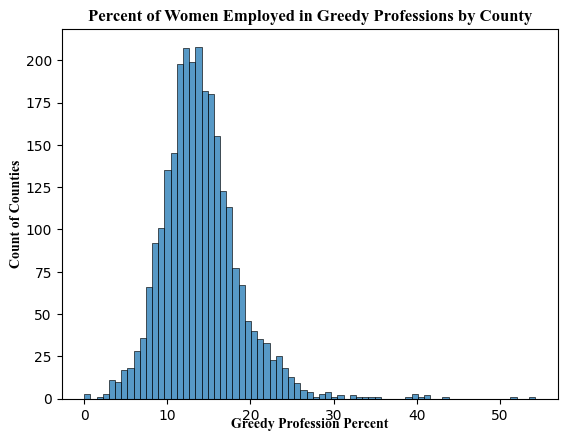

In [30]:
sns.histplot(data=model_df, x='greedy_profession_pct')

title_font = {
    'family': 'Times New Roman',
    'weight': 'bold',
    'verticalalignment': 'baseline',
    'horizontalalignment': 'center'
}

plt.title('Percent of Women Employed in Greedy Professions by County', fontdict=title_font)
plt.xlabel("Greedy Profession Percent", fontdict=title_font)
plt.ylabel("Count of Counties", fontdict=title_font)
plt.show()

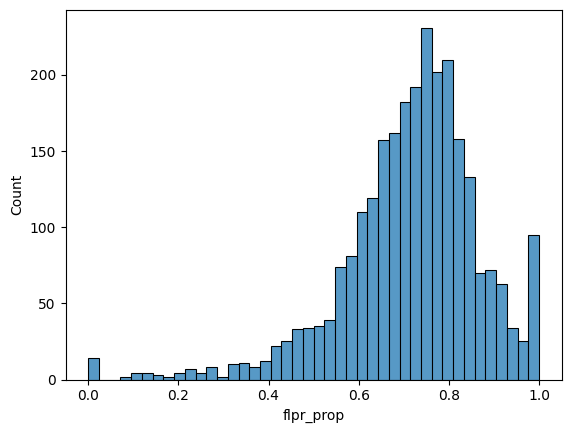

In [31]:
sns.histplot(data=model_df, x='flpr_prop')

In [32]:
model_df = model_df.dropna(subset=['flpr_prop']).copy()

n = len(model_df)

# transform flpr since beta dist cannot handle values that are exactly 0 or 1
model_df["flpr_beta"] = (model_df["flpr_prop"] * (n - 1) + 0.5) / n

## PGMs

### Naive Model

In [69]:
coords = {
    "counties": model_df["county_fips"].to_numpy()
}

# Boundary-adjusted outcome
y = model_df["flpr_beta"].to_numpy(dtype=float)

# Transform from the proportion scale to the logit scale
y_logit = logit(y)

with pm.Model(coords=coords) as naive_model:

    childcare_burden = pm.Data("childcare_burden", model_df["childcare_burden_pct_standardized"].to_numpy(dtype=float), dims="counties",)

    # Priors
    b0 = pm.Normal("b0", mu=logit(0.70), sigma=0.25,)

    bC = pm.Normal("bC",mu=0,sigma=0.15,)

    # Expected outcome on the logit scale
    mu_logit = pm.Deterministic("mu_logit", b0 + bC * childcare_burden, dims="counties",)

    # Residual variation on the logit scale
    sigma = pm.HalfNormal("sigma", sigma=1 )

    # Observed outcome on the logit scale
    flpr_logit = pm.Normal("flpr_logit",mu=mu_logit, sigma=sigma, observed=y_logit, dims="counties",)

    logit_normal_idata = pm.sample(draws=1000, tune=1000, chains=4, target_accept=0.9, random_seed=42)

naive_model.to_graphviz()

naive_graph = naive_model.to_graphviz() #

naive_graph.graph_attr["label"] = "Naive Model"
naive_graph.graph_attr["labelloc"] = "t" 
naive_graph.graph_attr["fontsize"] = "16"
naive_graph

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b0, bC, sigma]

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.

In [74]:
naive_graph.render('../assets/naive_model', format='png')

'../assets/naive_model.png'

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b0, bC, sigma]

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.

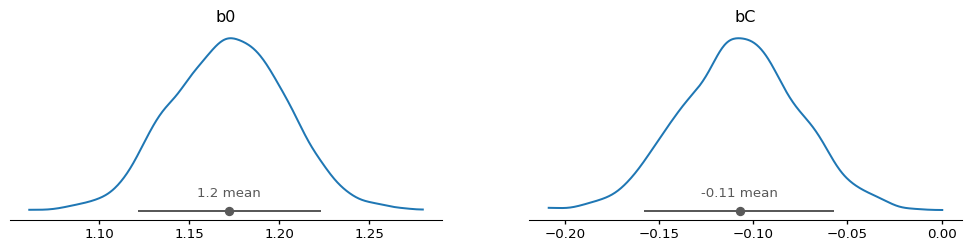

In [79]:
with naive_model:
  naive_idata = pm.sample()

az.plot_dist(
  naive_idata.posterior,
  var_names=['b0','bC']
);

plt.show()

In [83]:
az.summary(naive_idata, var_names=['b0','bC'])

In [77]:
from scipy.special import expit

b0_mean = naive_idata.posterior["b0"].mean().item()
b_childcare_burden_mean = naive_idata.posterior["bC"].mean().item()

flpr_average_burden = expit(b0_mean)
flpr_one_sd_higher = expit(b0_mean + b_childcare_burden_mean)

change_pp = (flpr_one_sd_higher- flpr_average_burden) * 100

print("FLPR at average burden:", flpr_average_burden * 100)
print("FLPR at +1 SD burden:", flpr_one_sd_higher * 100)
print("Change in percentage points:", change_pp)

FLPR at average burden: 76.34164282434186
FLPR at +1 SD burden: 74.34452579969559
Change in percentage points: -1.9971170246462666

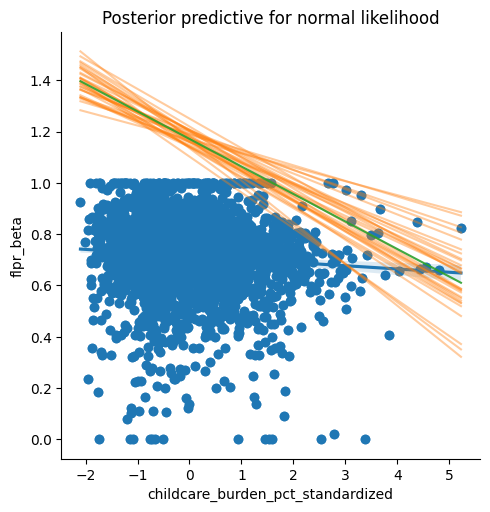

In [36]:
post = az.extract(naive_idata.posterior, num_samples=30)

x_plot = xr.DataArray(
  np.linspace(
    model_df['childcare_burden_pct_standardized'].min(),
    model_df['childcare_burden_pct_standardized'].max(),
    100
  ),
  dims="plot_id"
)
lines = post["b0"] + post["b_childcare_burden"] * x_plot
lines2 = b0_mean + b_childcare_burden_mean * x_plot

sns.lmplot(
  x='childcare_burden_pct_standardized', y='flpr_beta',
  data=model_df
);
plt.scatter(model_df['childcare_burden_pct_standardized'], model_df['flpr_beta'], label="data")
plt.plot(x_plot, lines.transpose(), alpha=0.4, color="C1")
plt.plot(x_plot, lines2.transpose(), alpha=0.9, color='C2')
plt.title("Posterior predictive for normal likelihood");
plt.show()

This plot shows that counties with higher childcare burden tend to have
slightly lower maternal FLPR. However, childcare burden alone explains
very little of the large county-to-county variation.

### Model 2: Childcare + Greedy Occupation

In [99]:
coords = {"counties": model_df["county_fips"].to_numpy()}

# Boundary-adjusted outcome
y = model_df["flpr_beta"].to_numpy(dtype=float)

# Transform from the proportion scale to the logit scale
y_logit = logit(y)

with pm.Model(coords=coords) as greedy_model:

    greedy_profession_share = pm.Data(
        "greedy_profession_share",
        model_df["greedy_profession_pct_standardized"].to_numpy(dtype=float),
        dims="counties",
    )

    childcare_burden = pm.Data(
        "childcare_burden",
        model_df["childcare_burden_pct_standardized"].to_numpy(dtype=float),
        dims="counties",
    )

    b0 = pm.Normal(
        "b0",
        mu=logit(0.70),
        sigma=0.25,
    )

    bC = pm.Normal(
        "bC",
        mu=0,
        sigma=0.15,
    )

    bCG = pm.Normal(
        "bCG",
        mu=0,
        sigma=0.15,
        )

    bG = pm.Normal(
        "bG",
        mu=0,
        sigma=0.15,
    )

    mu_logit = pm.Deterministic(
        "mu_logit",
        b0 + bC * childcare_burden
        + bG * greedy_profession_share
        + (bCG * childcare_burden * greedy_profession_share),
        dims="counties",
    )

    sigma = pm.HalfNormal(
        "sigma",
        sigma=1,
    )

    flpr_logit = pm.Normal(
        "flpr_logit",
        mu=mu_logit,
        sigma=sigma,
        observed=y_logit,
        dims="counties",
    )

    logit_normal_idata = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42,
    )

greedy_graph = greedy_model.to_graphviz()
greedy_graph.graph_attr["label"] = "Greedy Model"
greedy_graph.graph_attr["labelloc"] = "t" 
greedy_graph.graph_attr["fontsize"] = "16"
greedy_graph.graph_attr['rankdir'] = "TB"
greedy_graph

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b0, bC, bCG, bG, sigma]

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b0, bC, bCG, bG, sigma]

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.

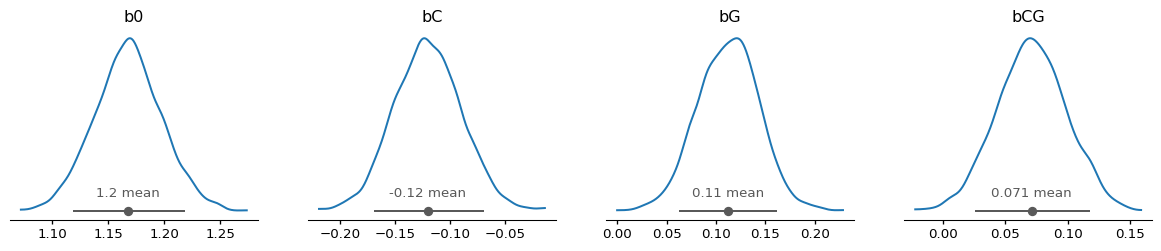

In [101]:
with greedy_model:
  greedy_idata = pm.sample()

az.plot_dist(
  greedy_idata.posterior,
  var_names=['b0','bC','bG','bCG'],
);

plt.show()

In [86]:
az.summary(greedy_idata, var_names=['b0','b_childcare_burden','b_greedy','b_interaction'])

In [87]:
# with greedy_model:
#     beta_ppc = pm.sample_posterior_predictive(
#         greedy_idata,
#         var_names=["flpr_logit"],
#         random_seed=42,
#     )

# az.plot_ppc_dist(
#     beta_ppc,
#     var_names=["flpr_logit"],
#     kind="kde",
# )

## Model 3: Education Model

In [102]:
coords = {
    "counties": model_df["county_fips"].to_numpy()
}

y = model_df["flpr_beta"].to_numpy(dtype=float)
y_logit = logit(y)

with pm.Model(coords=coords) as education_model:
    greedy_profession_share = pm.Data(
        "greedy_profession_share",
        model_df["greedy_profession_pct_standardized"].to_numpy(dtype=float),
        dims="counties",
    )

    childcare_burden = pm.Data(
        "childcare_burden",
        model_df["childcare_burden_pct_standardized"].to_numpy(dtype=float),
        dims="counties",
    )

    bachelors_plus = pm.Data(
        "bachelors_plus", model_df["bachelors_plus_share_standardized"].to_numpy(dtype=float),
        dims="counties"
    )

    b0 = pm.Normal(
        "b0",
        mu=logit(0.70),
        sigma=0.25,
    )

    bC = pm.Normal(
        "bC",
        mu=0,sigma=0.15,
    )

    bG = pm.Normal(
        "bG",
        mu=0,sigma=0.15,
    )

    bB =  pm.Normal(
        "bB",
        mu=0,sigma=0.15,
    )

    bCG = pm.Normal(
        "bCG",
        mu=0,sigma=0.15,
    )

    mu_logit = pm.Deterministic(
        "mu_logit",
       (b0 + (bC * childcare_burden) + (bG * greedy_profession_share) + (bB * bachelors_plus) 
        + (bCG * childcare_burden * greedy_profession_share)),
        dims="counties",
    )

    sigma = pm.HalfNormal(
        "sigma",sigma=1,
    )

    flpr_logit = pm.Normal(
        "flpr_logit",
        mu=mu_logit,
        sigma=sigma,
        observed=y_logit,
        dims="counties",
    )

    education_idata = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42,
    )

education_graph = education_model.to_graphviz()
education_graph.graph_attr["label"] = "Education Model"
education_graph.graph_attr["labelloc"] = "t" 
education_graph.graph_attr["fontsize"] = "16"
education_graph.graph_attr['rankdir'] = "TB"
education_graph

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b0, bC, bG, bB, bCG, sigma]

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.

In [105]:
az.summary(education_idata, var_names=['b0','bC','bG','bCG','bB'])

In [107]:
posterior = education_idata.posterior

b0 = posterior["b0"]
b_childcare_burden = posterior["bC"]
b_greedy = posterior["bG"]
b_bachelors_plus = posterior["bB"]
b_interaction = posterior["bCG"]

effects = {}

dict = {
    "low_greedy": -1,
    "average_greedy": 0,
    "high_greedy": 1,}

for label, greedy in dict.items():
    eta_at_average_burden = (
        b0
        + b_greedy * greedy
    )

    eta_at_high_burden = (b0 + b_childcare_burden + b_greedy * greedy + b_interaction * greedy)

    effects[f"burden_change_{label}_pp"] = 100 * (
        expit(eta_at_high_burden)
        - expit(eta_at_average_burden)
    )

az.summary(
    xr.Dataset(effects)
)

## Model 4: Rootedness

In [128]:
coords = {
    "counties": model_df["county_fips"].to_numpy()
}

y = model_df["flpr_beta"].to_numpy(dtype=float)
y_logit = logit(y)

with pm.Model(coords=coords) as rooted_model:
    greedy_profession_share = pm.Data(
        "greedy_profession_share",
        model_df[
            "greedy_profession_pct_standardized"
        ].to_numpy(dtype=float),
        dims="counties",
    )

    childcare_burden = pm.Data(
        "childcare_burden",
        model_df[
            "childcare_burden_pct_standardized"
        ].to_numpy(dtype=float),
        dims="counties",
    )

    bachelors_plus = pm.Data(
        "bachelors_plus", model_df["bachelors_plus_share_standardized"].to_numpy(dtype=float),
        dims="counties"
    )

    born_in_state = pm.Data(
        "born_in_state", model_df["born_in_state_pct_standardized"].to_numpy(dtype=float),
        dims="counties"
    )
    
    b0 = pm.Normal(
        "b0",
        mu=logit(0.70),
        sigma=0.25,
    )

    bC = pm.Normal(
        "bC",
        mu=0,
        sigma=0.15,
    )

    bG = pm.Normal(
        "bG",
        mu=0,
        sigma=0.15,
    )

    bB =  pm.Normal(
        "bB",
        mu=0,
        sigma=0.15,
    )

    bCG = pm.Normal(
        "bCG",
        mu=0,
        sigma=0.15,
    )

    bR = pm.Normal(
        "bR",
        mu=0,
        sigma=0.15
    )

    mu_logit = pm.Deterministic(
        "mu_logit",
       (b0 + (bC * childcare_burden) + (bG * greedy_profession_share) + (bB * bachelors_plus) 
        + (bCG * childcare_burden * greedy_profession_share) + (bR * born_in_state)),
        dims="counties",
    )

    sigma = pm.HalfNormal(
        "sigma",
        sigma=1,
    )

    flpr_logit = pm.Normal(
        "flpr_logit",
        mu=mu_logit,
        sigma=sigma,
        observed=y_logit,
        dims="counties",
    )

    rooted_idata = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42,
    )

rooted_graph = rooted_model.to_graphviz()
rooted_graph.graph_attr["label"] = "Rootedness Model"
rooted_graph.graph_attr["labelloc"] = "t" 
rooted_graph.graph_attr["fontsize"] = "16"
rooted_graph

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b0, bC, bG, bB, bCG, bR, sigma]

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.

In [129]:
az.summary(rooted_idata, var_names=['b0','bC','bG','bB','bCG','bR'])

In [130]:
rooted_parameter_names = {
    "b0": "Intercept (average county)",
    "bC": "Childcare cost burden",
    "bG": "Greedy occupation share",
    "bB": "Bachelor’s-plus attainment",
    "bCG": "Childcare burden × greedy occupation share",
    "bB": "Born-in-state share",
}

create_summary_table(rooted_idata, rooted_parameter_names)

In [131]:
posterior = rooted_idata.posterior

b0 = posterior["b0"]
bC = posterior["bC"]
bG = posterior["bG"]
bCG = posterior["bCG"]

dict = {"low_greedy": -1,
    "average_greedy": 0,
    "high_greedy": 1}

effects = {}

for label, greedy in dict.items():
    eta_at_average_burden = (
        b0
        + bG * greedy
    )

    eta_at_high_burden = (
        b0 + bC
        + bG * greedy
        + bCG * greedy
    )

    effects[f"burden_change_{label}_pp"] = 100 * (
        expit(eta_at_high_burden)
        - expit(eta_at_average_burden)
    )

az.summary(
    xr.Dataset(effects))

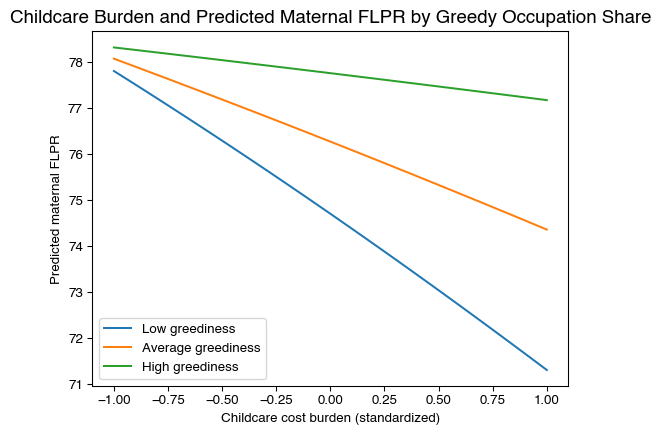

In [153]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Source Sans Pro', 'Helvetica', 'Arial', 'DejaVu Sans']

x_plot = xr.DataArray(
    np.linspace(-1, 1, 100),
    dims="plot_id"
)

greedy_levels = {
    "Low greediness": -1,
    "Average greediness": 0,
    "High greediness": 1
}

for label, g in greedy_levels.items():

    eta = (
        posterior["b0"]
        + posterior["bC"] * x_plot
        + posterior["bG"] * g
        + posterior["bCG"] * x_plot * g
    )

    predicted_flpr = expit(eta)

    mean_pred = predicted_flpr.mean(dim=("chain", "draw"))

    plt.plot(x_plot,mean_pred * 100,label=label)

plt.title("Childcare Burden and Predicted Maternal FLPR by Greedy Occupation Share", fontsize=14, fontweight='bold')
plt.xlabel("Childcare cost burden (standardized)")
plt.ylabel("Predicted maternal FLPR")
plt.legend()
plt.show()



## County Level Intercept

In [ ]:
model_df["county_fips_str"] = (
    model_df["county_fips"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(5)
)

model_df["state_fips"] = (
    model_df["county_fips_str"].str[:2]
)

state_codes, state_idx = np.unique(
    model_df["state_fips"],
    return_inverse=True,
)

model_df[
    ["county_fips_str", "state_fips"]
].head()

In [ ]:
coords = {
    "counties": model_df["county_fips_str"].to_numpy(),
    "states": state_codes,
}

from scipy.special import logit
import numpy as np
import pymc as pm

y = model_df["flpr_beta"].to_numpy(dtype=float)
y_logit = logit(y)

with pm.Model(coords=coords) as state_model:

    childcare_burden = pm.Data(
        "childcare_burden",
        model_df[
            "childcare_burden_pct_standardized"
        ].to_numpy(dtype=float),
        dims="counties",
    )

    greedy_profession_share = pm.Data(
        "greedy_profession_share",
        model_df[
            "greedy_profession_pct_standardized"
        ].to_numpy(dtype=float),
        dims="counties",
    )

    bachelors_plus_share = pm.Data(
        "bachelors_plus_share",
        model_df[
            "bachelors_plus_share_standardized"
        ].to_numpy(dtype=float),
        dims="counties",
    )

    state_index = pm.Data(
        "state_index",
        state_idx,
        dims="counties",
    )

    # Overall intercept and slopes
    b0 = pm.Normal(
        "b0",
        mu=logit(0.70),
        sigma=0.25,
    )

    b_childcare_burden = pm.Normal("b_childcare_burden", 0, 0.15)
    b_greedy = pm.Normal("b_greedy", 0, 0.15)
    b3 = pm.Normal("b3", 0, 0.15)

    b_interaction = pm.Normal(
        "b_interaction",
        0,
        0.10,
    )

    # State-level variation
    sigma_state = pm.HalfNormal(
        "sigma_state",
        sigma=0.25,
    )

    state_offset = pm.Normal(
        "state_offset",
        mu=0,
        sigma=1,
        dims="states",
    )

    state_effect = pm.Deterministic(
        "state_effect",
        state_offset * sigma_state,
        dims="states",
    )

    mu_logit = pm.Deterministic(
        "mu_logit",
        (
            b0
            + b_childcare_burden * childcare_burden
            + b_greedy * greedy_profession_share
            + b3 * bachelors_plus_share
            + b_interaction
              * childcare_burden
              * greedy_profession_share
            + state_effect[state_index]
        ),
        dims="counties",
    )

    sigma = pm.HalfNormal(
        "sigma",
        sigma=1,
    )

    flpr_logit = pm.Normal(
        "flpr_logit",
        mu=mu_logit,
        sigma=sigma,
        observed=y_logit,
        dims="counties",
    )

    state_idata = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b0, b_childcare_burden, b_greedy, b3, b_interaction, sigma_state, state_offset, sigma]

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.

In [ ]:
az.summary(
    state_idata,
    var_names=[
        "b_childcare_burden",
        "b_greedy",
        "b3",
        "b_interaction",
        "sigma_state",
    ]
)

In [ ]:
import arviz as az
import xarray as xr
from scipy.special import expit

posterior = state_idata.posterior

b0 = posterior["b0"]
b_childcare_burden = posterior["b_childcare_burden"]
b_greedy = posterior["b_greedy"]
b_interaction = posterior["b_interaction"]

effects = {}

for label, greedy in {
    "low_greedy": -1,
    "average_greedy": 0,
    "high_greedy": 1,
}.items():

    eta_at_average_burden = (
        b0
        + b_greedy * greedy
    )

    eta_at_high_burden = (
        b0
        + b_childcare_burden
        + b_greedy * greedy
        + b_interaction * greedy
    )

    effects[f"burden_change_{label}_pp"] = 100 * (
        expit(eta_at_high_burden)
        - expit(eta_at_average_burden)
    )

az.summary(
    xr.Dataset(effects)
)

## Sensitivity Analysis

In [ ]:
import statsmodels.formula.api as smf
import sensemakr as smkr

sensitivity_df = model_df.copy()

# Outcome used in the PyMC model
sensitivity_df["flpr_logit"] = logit(
    sensitivity_df["flpr_beta"].astype(float)
)

# Shorter variable names make the formulas easier to manage
sensitivity_df["burden"] = (
    sensitivity_df["childcare_burden_pct_standardized"]
)

sensitivity_df["greedy"] = (
    sensitivity_df["greedy_profession_pct_standardized"]
)

sensitivity_df["bachelors"] = (
    sensitivity_df["bachelors_plus_share_standardized"]
)

sensitivity_df["born_in_state"] = (
    sensitivity_df['born_in_state_pct_standardized']
)


ols_model = smf.ols(
    formula=(
        "flpr_logit ~ "
        "burden * greedy "
        "+ bachelors + born_in_state"
    ),
    data=sensitivity_df,
).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:             flpr_logit   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     13.11
Date:                Wed, 05 Aug 2026   Prob (F-statistic):           1.23e-12
Time:                        22:16:07   Log-Likelihood:                -5051.2
No. Observations:                2653   AIC:                         1.011e+04
Df Residuals:                    2647   BIC:                         1.015e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.1726      0.032     37.072

In [ ]:
education_sense = smkr.Sensemakr(model = ols_model,
                              treatment = "burden",
                              benchmark_covariates = ["bachelors"],
                              kd = [1,2,3])

education_sense.ovb_minimal_reporting(format = "html")

/opt/anaconda3/envs/MyNewEnv/lib/python3.12/site-packages/sensemakr/sensitivity_statistics.py:177: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/opt/anaconda3/envs/MyNewEnv/lib/python3.12/site-packages/sensemakr/sensitivity_statistics.py:177: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
